# Feature Scaling — Standardization & Normalization

`02_ML_Roadmap.MD` item 5: **"Normalizing & Standardization — put features
on the same scale (Min-Max vs Z-score) so no single feature dominates just
because its numbers are bigger."** This is different from outlier
*removal* (`12_Outlier.ipynb` → `14_Outlier_Removal_Z_Score.ipynb`, which
drop rows) — scaling touches **every** row, drops **none**, and only
changes the *units* a column is measured in.

Two techniques, same goal:

| | Formula | Result |
|---|---|---|
| **Standardization** (Z-score) | `X_new = (Xi − X_mean) / std` | centered at 0, spread ≈ 1 std |
| **Normalization** (Min-Max) | `X_new = (Xi − X_min) / (X_max − X_min)` | squeezed into `[0, 1]` |

Section 1 runs Standardization on `ApplicantIncome` (the column
`12_Outlier.ipynb` used); Section 5 runs Normalization on
`CoapplicantIncome` (the column `14_Outlier_Removal_Z_Score.ipynb` used) —
reusing familiar columns so only the *technique* changes, not the data.
The three questions this notebook answers along the way: **does scaling
remove outliers, what does `describe()` mean afterward, and does scaling
change the data's shape?**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
dataset = pd.read_csv("loans.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y


In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

## 0. Setup — and a Bug Worth Fixing First

`ApplicantIncome` has 2 missing values, same gap `12_Outlier.ipynb` worked
around. Filling it the *obvious* way first, on purpose, to show why it
silently doesn't work:

In [4]:
dataset["ApplicantIncome"].fillna(dataset["ApplicantIncome"].mean(), inplace=True)
dataset["ApplicantIncome"].isnull().sum()

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_45413/1792826338.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset["ApplicantIncome"].fillna(dataset["ApplicantIncome"].mean(), inplace=True)


np.int64(2)

Still **2** — and the `ChainedAssignmentError` warning above explains
why: `dataset["ApplicantIncome"].fillna(..., inplace=True)` is chained
indexing. Under pandas' Copy-on-Write, `dataset["ApplicantIncome"]` hands
back a *copy*, so `inplace=True` patches that throwaway copy — `dataset`
itself never changes. Pandas' own suggested fix: call `.fillna` on
`dataset` directly with a `{column: value}` dict.

In [5]:
dataset.fillna({"ApplicantIncome": dataset["ApplicantIncome"].mean()}, inplace=True)
dataset["ApplicantIncome"].isnull().sum()

np.int64(0)

**0** — fixed. All 618 rows now carry a real `ApplicantIncome`
value, so every `count` in this notebook reads `618`, not `616`. (Worth
remembering when reading `describe()` further down — a `count` that's
lower than the row total is usually this exact bug, not a real data gap.)

In [6]:
dataset["ApplicantIncome"].describe()

count      618.000000
mean      4730.256494
std       2177.405150
min       1500.000000
25%       3162.000000
50%       4334.500000
75%       5807.000000
max      16981.000000
Name: ApplicantIncome, dtype: float64

Raw shape: `mean` (4730.26) sits above the `median`/`50%` (4334.5) —
the same right-skew `12_Outlier.ipynb` found, now with a clean 618-row
count behind it.

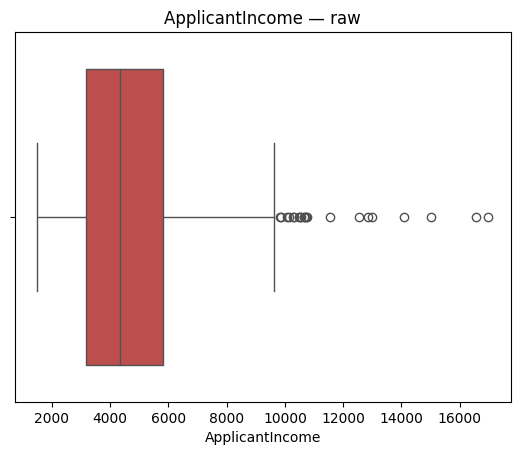

In [7]:
sns.boxplot(x=dataset["ApplicantIncome"], color="#d03b3b")
plt.title("ApplicantIncome — raw")
plt.show()

Same string of outlier dots past the right whisker as
`12_Outlier.ipynb`. Exactly **21** points, by the standard
`Q3 + 1.5×IQR` rule — confirmed with numbers in Section 3, kept in mind for
comparison after scaling.

## 1. Standardization — `StandardScaler`

`ss.fit(...)` learns two numbers from the column — `mean_` and `scale_`
(population std, i.e. divided by `N`, not `N-1`) — and `ss.transform(...)`
applies `(x − mean_) / scale_` to every value.

In [8]:
ss = StandardScaler()
ss.fit(dataset[["ApplicantIncome"]])
dataset["ApplicantIncome_SS"] = ss.transform(dataset[["ApplicantIncome"]])
dataset[["ApplicantIncome", "ApplicantIncome_SS"]].head(3)

,ApplicantIncome,ApplicantIncome_SS
0,1686.0,-1.399245
1,2437.0,-1.054059
2,8313.0,1.646752


Check row 0 by hand: `(1686 − 4730.26) / 2175.64 ≈ -1.399` — matches
`ApplicantIncome_SS` above exactly. Note `ss.scale_` (**2175.64**) is
*not* the same number `describe()` reports as `std` (**2177.41**) — that
gap is the subject of Section 2's first surprise.

## 2. Reading `describe()` on `ApplicantIncome_SS`, Value by Value

In [9]:
dataset["ApplicantIncome_SS"].describe()

count    6.180000e+02
mean    -1.422810e-16
std      1.000810e+00
min     -1.484737e+00
25%     -7.208244e-01
50%     -1.819033e-01
75%      4.949082e-01
max      5.630862e+00
Name: ApplicantIncome_SS, dtype: float64

Row by row, against the raw `describe()` above:

- **`count` = 618** — not 616. Confirms Section 0's fix actually worked;
  the old bug would have leaked 2 `NaN`s straight through
  `(NaN − mean) / std = NaN` into this column too.
- **`mean` = -1.42e-16** — as good as exactly **0**. Standardization is
  *defined* to center the mean at 0; this isn't rounding error in the
  concept, it's rounding error in 64-bit floats representing an exact 0.
- **`std` = 1.000810** — close to 1, but not exactly. This is *not* a bug:
  `StandardScaler` divides by the **population** std (`÷N`), but pandas'
  `.std()` inside `describe()` uses the **sample** std (`÷(N-1)`,
  Bessel's correction) by default. The ratio between them is exactly
  `sqrt(N/(N-1))` = `sqrt(618/617)` = **1.000810** — matches to 6 decimal
  places. Two different, both-correct definitions of "standard deviation,"
  disagreeing by a predictable amount.
- **`min` = -1.484737** ↔ raw `min` **1500** — the least-poor applicant is
  `(1500 − 4730.26) / 2175.64 ≈ -1.48` std devs *below* the mean.
- **`25%` = -0.720824** ↔ raw **3162** — a quarter of applicants earn
  under 0.72 std devs below average.
- **`50%` = -0.181903** ↔ raw **4334.5**, the median — slightly negative,
  confirming the mean (pulled up by the right tail) sits *above* the
  typical applicant, i.e. the skew already visible in Section 0.
- **`75%` = 0.494908** ↔ raw **5807**.
- **`max` = 5.630862** ↔ raw **16981** — the single richest applicant is
  **5.6 standard deviations** above the mean. That's the same top outlier
  the boxplot flagged; scaling didn't hide it, it just re-labeled it in σ
  units instead of ₹.

## 3. Does Scaling Remove Outliers?

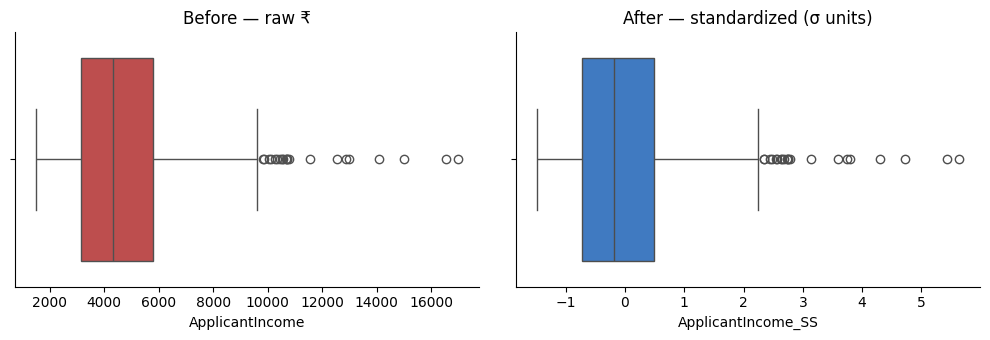

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.boxplot(x=dataset["ApplicantIncome"], color="#d03b3b", ax=axes[0])
axes[0].set_title("Before — raw ₹")
sns.boxplot(x=dataset["ApplicantIncome_SS"], color="#2a78d6", ax=axes[1])
axes[1].set_title("After — standardized (σ units)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Same number of dots past the whiskers in both plots — just relabeled
on the x-axis. Confirmed with the actual IQR rule, not just eyeballing:

In [11]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())

print("raw outliers:     ", iqr_outlier_count(dataset["ApplicantIncome"]))
print("standardized outliers:", iqr_outlier_count(dataset["ApplicantIncome_SS"]))

raw outliers:      21
standardized outliers: 21


**21 and 21 — identical.** Answer to "does scaling remove outliers":
**no.** Standardization is a strictly increasing linear transform
(multiply by a positive `1/scale_`, then shift by `-mean_/scale_`) applied
to *every* point, including `Q1` and `Q3` themselves. So "further than
`Q3 + 1.5×IQR`" before scaling is exactly equivalent to "further than
`Q3' + 1.5×IQR'`" after — the same points end up flagged, just measured in
different units. Removing outliers is the deliberate, separate job of
`12_Outlier.ipynb`–`14_Outlier_Removal_Z_Score.ipynb`; scaling moves
*everyone* together and leaves who's-extreme completely untouched.

## 4. Does Scaling Change the Data's *Nature* (Shape)?

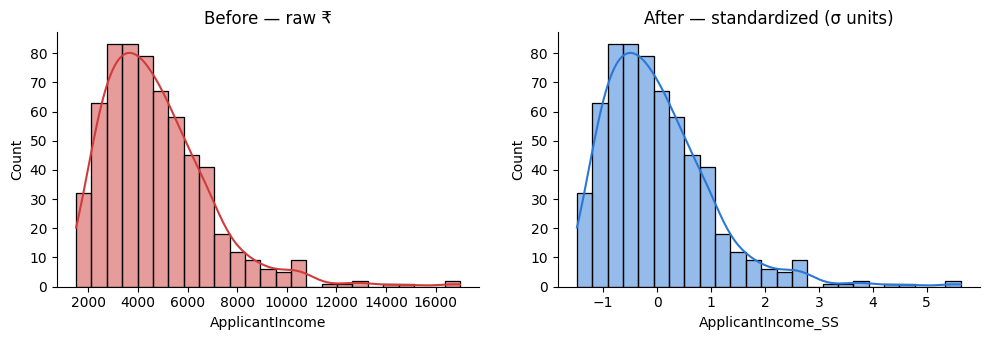

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(dataset["ApplicantIncome"], kde=True, color="#d03b3b", ax=axes[0])
axes[0].set_title("Before — raw ₹")
sns.histplot(dataset["ApplicantIncome_SS"], kde=True, color="#2a78d6", ax=axes[1])
axes[1].set_title("After — standardized (σ units)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

(This is the corrected version of the original draft's before/after
plot — that one had the titles swapped, labeling the *scaled* column
"Before" and the *raw* column "After.") Side by side, the two curves are
the same shape — same right-skew, same bump position relative to the rest
of the curve — just stretched onto a different x-axis. Proof, numerically,
not just by eye:

In [13]:
print("skew     — raw:", dataset["ApplicantIncome"].skew(), " scaled:", dataset["ApplicantIncome_SS"].skew())
print("kurtosis — raw:", dataset["ApplicantIncome"].kurt(), " scaled:", dataset["ApplicantIncome_SS"].kurt())

skew     — raw: 1.5834164129556014  scaled: 1.5834164129556014
kurtosis — raw: 4.444551633369553  scaled: 4.444551633369551


Skew matches to **13+ decimal places**; kurtosis differs only at the
**13th** decimal (float noise, not a real difference). Both are exactly
equal because skewness and kurtosis are *scale-and-location invariant* —
they're built from `(x − mean)` divided by `std`, raised to a power, which
is the same ratio standardization itself computes. A transform that only
shifts and rescales an axis mathematically **cannot** move these numbers.
That's the rigorous version of "the data's nature is not changed":
standardization changes *where the ruler's 0 and 1 are*, never *the shape
of what's being measured*.

**The same fact, in two dimensions.** Standardizing `ApplicantIncome`
*and* `CoapplicantIncome` together and plotting one against the other —
this is the whiteboard sketch (scatter cloud, off in a corner → same cloud,
re-centered on the axes) made real with actual data:

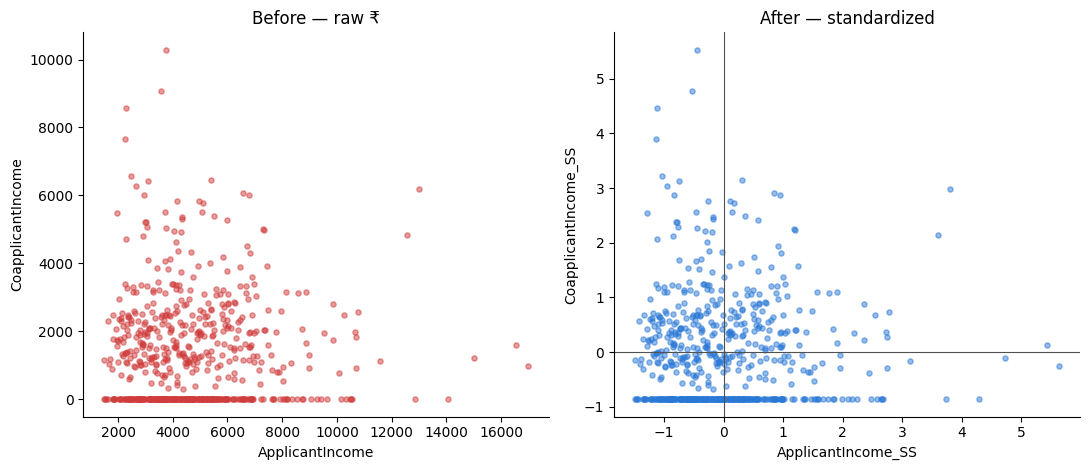

In [14]:
scaled_2d = StandardScaler().fit_transform(dataset[["ApplicantIncome", "CoapplicantIncome"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].scatter(dataset["ApplicantIncome"], dataset["CoapplicantIncome"], s=14, alpha=0.5, color="#d03b3b")
axes[0].set_title("Before — raw ₹")
axes[0].set_xlabel("ApplicantIncome"); axes[0].set_ylabel("CoapplicantIncome")

axes[1].scatter(scaled_2d[:, 0], scaled_2d[:, 1], s=14, alpha=0.5, color="#2a78d6")
axes[1].axhline(0, color="#52514e", linewidth=0.8)
axes[1].axvline(0, color="#52514e", linewidth=0.8)
axes[1].set_title("After — standardized")
axes[1].set_xlabel("ApplicantIncome_SS"); axes[1].set_ylabel("CoapplicantIncome_SS")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The cloud slides so its center sits on `(0, 0)` and stretches to a
new scale — but the cloud's *shape* (which points are bunched together,
which sit apart, the skew toward the top-right) is identical in both
panels. Nothing about the data moved *relative to itself*; only where the
axes' origin and unit-length are drawn moved.

## 5. Normalization — Min-Max Scaling `CoapplicantIncome`

`CoapplicantIncome` has 0 missing values (same reason `14` picked it) —
no fillna detour needed. Min-Max uses `X_min`/`X_max` directly instead of
`mean`/`std`.

In [15]:
mm = MinMaxScaler()
dataset["CoapplicantIncome_MM"] = mm.fit_transform(dataset[["CoapplicantIncome"]])
dataset[["CoapplicantIncome", "CoapplicantIncome_MM"]].head(3)

,CoapplicantIncome,CoapplicantIncome_MM
0,1020,0.099145
1,1201,0.116738
2,1065,0.103519


In [16]:
dataset["CoapplicantIncome_MM"].describe()

count    618.000000
mean       0.134630
std        0.156664
min        0.000000
25%        0.000000
50%        0.105851
75%        0.215567
max        1.000000
Name: CoapplicantIncome_MM, dtype: float64

Against the raw `CoapplicantIncome` stats (`min` 0, `max` 10288):

- **`min` = 0.0, `max` = 1.0**, exactly — by construction, `(X_min − X_min)/(range) = 0`
  and `(X_max − X_min)/(range) = 1`. Min-Max *guarantees* the endpoints;
  Standardization never guaranteed any specific min/max at all.
- **`mean` = 0.1346, `std` = 0.1567** — nowhere near `(0, 1)`. Min-Max only
  fixes the *endpoints*; the mean/std land wherever the raw distribution's
  own mean/spread happen to fall inside that `[0, 1]` window. A mean this
  low (0.13, not 0.5) is a symptom of the same right-skew as `ApplicantIncome`:
  most coapplicants cluster near the low end, one huge value stretches the
  range up to 1.
- **`25%` = 0.0** — literally a quarter of coapplicants report **0** raw
  income, so their scaled value is exactly the floor too.
- **`50%` = 0.1059, `75%` = 0.2157** — most of the data lives in the
  bottom fifth of the `[0, 1]` range; the last 79% of that range belongs to
  a small number of high earners.

In [17]:
print("raw outliers:      ", iqr_outlier_count(dataset["CoapplicantIncome"]))
print("min-max outliers:  ", iqr_outlier_count(dataset["CoapplicantIncome_MM"]))
print()
print("skew — raw:", dataset["CoapplicantIncome"].skew(), " min-max:", dataset["CoapplicantIncome_MM"].skew())

raw outliers:       15
min-max outliers:   15

skew — raw: 1.5399420730801827  min-max: 1.5399420730801823


**15 and 15**, skew matching to 13+ decimals — the same two
conclusions from Sections 3–4 hold for Normalization too: outliers aren't
removed, shape isn't changed. Min-Max is just a different formula for the
same kind of transform (linear, applied uniformly to every point).

## 6. Standardization vs. Normalization — Which One, When

Both are linear, both preserve shape, neither removes outliers — so the
real difference is *sensitivity to outliers while fitting*:

- **Standardization** uses `mean`/`std`. A single extreme value pulls both,
  but a std is a squared-then-rooted average across *all* points, so one
  outlier's influence is diluted by the other 617.
- **Min-Max** uses `X_min`/`X_max` directly — the *literal* most extreme
  point defines an endpoint of the output range. One outlier doesn't just
  influence the scale, it **is** the scale.

Concretely, on this exact column:

In [18]:
below_tenth = (dataset["CoapplicantIncome_MM"] < 0.1).sum()
print(f"{below_tenth} of 618 coapplicants ({below_tenth/618:.1%}) land below 0.1 on a 0–1 scale")
print("because a single value —", dataset['CoapplicantIncome'].max(), "— alone stretches the range up to 1.0")

297 of 618 coapplicants (48.1%) land below 0.1 on a 0–1 scale
because a single value — 10288 — alone stretches the range up to 1.0


**297 of 618 (48%)** get crushed into the bottom tenth of the `[0, 1]`
range, purely because the max (`10288`) is so far from the typical value.
This is exactly why running outlier detection (`12`–`14`) *before* Min-Max
matters more than it does before Standardization: Min-Max hands the
top-of-range slot to whatever the largest value is, outlier or not. As a
default: Standardization is the safer everyday choice (most models — KNN,
K-Means, PCA, anything gradient-descent-based — assume roughly this);
reach for Min-Max specifically when an algorithm *needs* a bounded `[0, 1]`
input (e.g. some neural-net input layers), and consider handling outliers
first if you do.

## 7. Why This Actually Matters — a Distance Example

`02_ML_Roadmap.MD`'s own justification for item 5: *"a distance-based
algorithm would treat a ₹1,000 income difference as 'bigger' than a
50-point credit-score difference, purely because of units."* Same idea,
concretely, with two real applicants who differ in **both**
`ApplicantIncome` and `Credit_History`:

In [19]:
dataset.fillna({"Credit_History": dataset["Credit_History"].mode()[0]}, inplace=True)

a, b = dataset.iloc[1], dataset.iloc[4]
print("applicant 1:", a["ApplicantIncome"], a["Credit_History"])
print("applicant 4:", b["ApplicantIncome"], b["Credit_History"])

income_gap2 = (a["ApplicantIncome"] - b["ApplicantIncome"]) ** 2
credit_gap2 = (a["Credit_History"] - b["Credit_History"]) ** 2
raw_dist = np.sqrt(income_gap2 + credit_gap2)
print(f"\nraw euclidean distance: {raw_dist:.2f}")
print(f"  ApplicantIncome's share of that distance:  {income_gap2/(income_gap2+credit_gap2):.4%}")
print(f"  Credit_History's share of that distance:   {credit_gap2/(income_gap2+credit_gap2):.4%}")

applicant 1: 2437.0 1.0
applicant 4: 3002.0 0.0

raw euclidean distance: 565.00
  ApplicantIncome's share of that distance:  99.9997%
  Credit_History's share of that distance:   0.0003%


Applicant 1 earns ₹2437, applicant 4 earns ₹3002 — a modest ₹565
gap. But their `Credit_History` (a strong real signal for loan approval)
differs too: 1.0 vs 0.0. In raw units, income's much bigger numbers
completely swamp the distance — **Credit_History contributes 0.003%**,
essentially invisible to any distance-based algorithm. Now the same pair,
standardized first:

In [20]:
scaled_pair = StandardScaler().fit_transform(dataset[["ApplicantIncome", "Credit_History"]])
sa, sb = scaled_pair[1], scaled_pair[4]

s_income_gap2 = (sa[0] - sb[0]) ** 2
s_credit_gap2 = (sa[1] - sb[1]) ** 2
scaled_dist = np.sqrt(s_income_gap2 + s_credit_gap2)
print(f"scaled euclidean distance: {scaled_dist:.2f}")
print(f"  ApplicantIncome's share of that distance:  {s_income_gap2/(s_income_gap2+s_credit_gap2):.4%}")
print(f"  Credit_History's share of that distance:   {s_credit_gap2/(s_income_gap2+s_credit_gap2):.4%}")

scaled euclidean distance: 2.81
  ApplicantIncome's share of that distance:  0.8548%
  Credit_History's share of that distance:   99.1452%


The shares **flip**: `Credit_History` now drives **99.15%** of the
distance, income only 0.85%. Nothing about which applicants are "similar"
changed in reality — only the ruler did. A ₹565 gap is tiny relative to
income's own spread (std ≈ ₹2176 → 0.26σ), while a full 0-vs-1 swing in a
binary column *is* essentially its entire spread (std ≈ 0.37 → ~2.7σ).
Pre-scaling, `Credit_History` — despite mattering enormously for whether a
loan gets repaid — would be almost completely ignored by any Euclidean
distance calculation (KNN, K-Means, ...) simply because it happens to be
measured in units of 1s instead of thousands.

## Summary

- **Standardization** (`X_new = (Xi − mean)/std`): centers at 0, spreads
  to ≈1 std, unbounded range.
- **Normalization** (`X_new = (Xi − min)/(max − min)`): bounded to
  `[0, 1]` exactly, more sensitive to outliers since a single extreme
  value defines an endpoint.
- **Neither removes outliers** — proven with matching IQR counts before
  and after, for both techniques (Sections 3, 5). Outlier removal
  (`12`–`14`) is a separate, earlier decision.
- **Neither changes the data's shape/nature** — proven with matching
  skew/kurtosis to 13+ decimal places, for both techniques (Sections 4, 5).
  Both are purely linear (shift + rescale) transforms, and shape statistics
  are invariant to exactly that kind of transform.
- What scaling *does* do: put differently-united columns on a comparable
  footing, so distance-based algorithms and gradient descent don't
  accidentally let one feature dominate just because its raw numbers are
  bigger (Section 7).